<a href="https://colab.research.google.com/github/antoniopioricciardi/sam3_demo/blob/main/sam3_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install -U huggingface_hub!

In [2]:
!pip install -q transformers accelerate torch torchvision

In [3]:
from google.colab import userdata
from huggingface_hub import login

# Retrieve the token from Colab Secrets
hf_token = userdata.get('HF_TOKEN')

# Login to Hugging Face
if hf_token:
    login(token=hf_token, add_to_git_credential=True)
    print('Logged in successfully!')
else:
    print('Please add your HF_TOKEN to the Colab Secrets (🔑 icon) first.')

Logged in successfully!


In [4]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests
from google.colab import userdata

In [5]:
# Retrieve the token
hf_token = userdata.get('HF_TOKEN')
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model and processor passing the token explicitly
model = Sam3Model.from_pretrained("facebook/sam3", token=hf_token).to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3", token=hf_token)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

In [6]:
# Load image
image_url = "http://images.cocodataset.org/val2017/000000077595.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

In [11]:

# Segmentation
inputs = processor(images=image, text="key", return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-processing
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist()
)[0]

print(f"Found {len(results['masks'])} objects")

Found 26 objects


In [12]:
results

{'scores': tensor([0.6291, 0.5749, 0.5824, 0.5742, 0.5528, 0.5510, 0.5650, 0.5397, 0.6226,
         0.5912, 0.5686, 0.5709, 0.5661, 0.5207, 0.5931, 0.5700, 0.5533, 0.5662,
         0.5671, 0.5680, 0.5636, 0.6302, 0.6428, 0.6035, 0.5568, 0.5980],
        device='cuda:0'),
 'boxes': tensor([[128.1261, 364.4946, 172.8027, 391.6064],
         [ 24.8816, 305.7227,  56.7793, 321.0964],
         [166.2985, 299.6748, 205.6242, 317.5506],
         [  1.4608, 325.8934,  32.7554, 342.0199],
         [ 94.5753, 328.3734, 129.7345, 346.3694],
         [ 24.4970, 360.2593,  60.5006, 379.8268],
         [106.6450, 293.4053, 138.6841, 309.2931],
         [ -1.6142, 311.7267,  15.9273, 326.9031],
         [ 19.0895, 379.7151,  75.6719, 414.9186],
         [126.2521, 305.3702, 160.0591, 322.8235],
         [137.9257, 321.3973, 178.6136, 340.6373],
         [ 67.1549, 299.2098,  98.9402, 316.0404],
         [ 50.5842, 334.9803,  86.1850, 353.6790],
         [195.3167, 271.7379, 234.8270, 286.0038],
     

In [13]:
import numpy as np
import matplotlib

def overlay_masks(image, masks):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


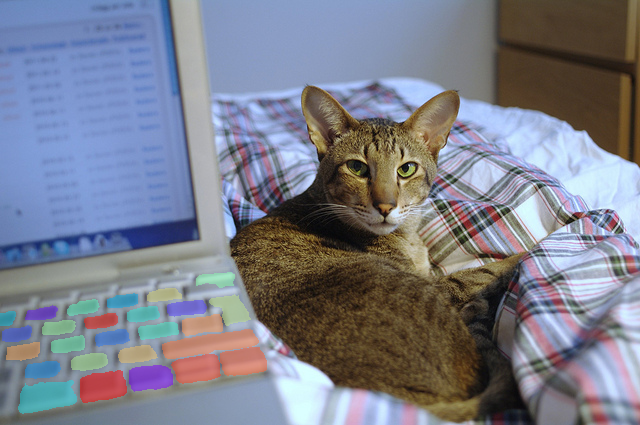

In [14]:
overlay_masks(image, results["masks"])
